# Ex : 7
# SUPPORT VECTOR MACHINE (SVM) CLASSIFIER

---

### Objective:
To implement Support Vector Machine (SVM) algorithm for classification and understand its working principles, kernel tricks, and hyperparameter tuning.

### Dataset:
Credit card Fraud Dataset (Kaggle)

### Algorithm Overview:
Support Vector Machine is a supervised learning algorithm that finds the optimal hyperplane which best separates different classes in the feature space. It aims to maximize the margin between the closest points of different classes (support vectors).



----
### **Step-by-Step Approach for Credit Card Fraud Detection**

#### **Step 1: Import Required Libraries**
* Import essential libraries: `NumPy`, `Pandas`, `Matplotlib`, `Seaborn`.
* Import `scikit-learn` modules for SVM, data preprocessing, and evaluation metrics.

#### **Step 2: Load and Explore the Dataset**
* Load the Credit Card Fraud dataset.
* Perform initial exploration: check dataset shape, class distribution, and missing values.

#### **Step 3: Balance the Dataset**
* Handle class imbalance by downsampling the majority class (normal transactions).
* Create a balanced dataset (e.g., 984 normal and 492 fraudulent transactions).

#### **Step 4: Split and Scale the Data**
* Separate features ($X$) and target ($y$).
* Split into training (80%) and testing (20%) sets.
* Apply `StandardScaler` to normalize features for optimal SVM performance.

#### **Step 5: Train SVM with Different Kernels**
* Train SVM classifiers using different kernels:
    * **Linear**
    * **Polynomial**
    * **RBF (Radial Basis Function)**
    * **Sigmoid**

#### **Step 6: Evaluate and Compare Kernel Performance**
* Compare accuracy scores across different kernels.
* Use a **bar chart** visualization to identify the best-performing kernel.

#### **Step 7: Detailed Analysis of Best Model**
* Select the top-performing kernel.
* Generate a **Classification Report** (Precision, Recall, F1-Score).
* Plot a **Confusion Matrix** to analyze false positives and false negatives.


---

## Step 1: Import Required Libraries

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


### Explanation:
- **numpy, pandas**: For data manipulation and analysis
- **matplotlib, seaborn**: For data visualization
- **sklearn**: Provides SVM implementation and evaluation metrics
- **PCA**: For dimensionality reduction (helps in visualization)
- **GridSearchCV**: For hyperparameter tuning

## Step 2: Load and Explore the Dataset

In [4]:
# Step 2: Load the dataset
file_path = r"E:\Z_Arise\ML_Lab\creditcard.csv"

df = pd.read_csv(file_path)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("\n" + "="*60)
print("CREDIT CARD FRAUD DATASET")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraudulent transactions: {df['Class'].sum()} ({df['Class'].mean()*100:.4f}%)")



CREDIT CARD FRAUD DATASET
Dataset shape: (284807, 31)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798

In [6]:
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES CHECK")
print("="*50)
print(df.isnull().sum())


MISSING VALUES CHECK
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### Explanation:
- The Wine Quality dataset contains 1599 samples with 12 features
- Features are chemical properties of wine (all numerical)
- Target variable 'quality' ranges from 3 to 8
- No missing values in the dataset (good for SVM)
- Features have different scales (will need normalization)

----
## Step 3: Data Preprocessing for SVM

In [7]:
# Step 3: Data Preprocessing
X = df.drop('Class', axis =1)
y = df['Class']

# Simple downsampling of majority class (for faster training)
# This is a simple approach - for production, use SMOTE or other techniques
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(n=len(fraud) * 2, random_state=42)

df_balanced = pd.concat([fraud, normal])
X_balanced = df_balanced.drop('Class', axis=1)
y_balanced = df_balanced['Class']

print(f"\nBalanced dataset shape: {X_balanced.shape}")
print(f"Balanced class distribution:\n{y_balanced.value_counts()}")


Balanced dataset shape: (1476, 30)
Balanced class distribution:
Class
0    984
1    492
Name: count, dtype: int64


In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 1180 samples
Testing set size: 296 samples


In [9]:
# Scale the features (CRITICAL for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Why Scaling is Critical for SVM:
- SVM tries to maximize the margin between classes
- Features with larger scales would dominate the distance calculation
- Standard scaling ensures all features contribute equally
- Without scaling, the SVM hyperplane would be biased

----
## Step 5 : Non linear SVM


SVM PERFORMANCE WITH DIFFERENT KERNELS

📊 Training SVM with LINEAR kernel...
   Test Accuracy: 0.9662
   Support Vectors: [68 62]
   Total Support Vectors: 130

📊 Training SVM with POLY kernel...
   Test Accuracy: 0.8919
   Support Vectors: [204 186]
   Total Support Vectors: 390

📊 Training SVM with RBF kernel...
   Test Accuracy: 0.9493
   Support Vectors: [134 128]
   Total Support Vectors: 262

📊 Training SVM with SIGMOID kernel...
   Test Accuracy: 0.9223
   Support Vectors: [80 77]
   Total Support Vectors: 157


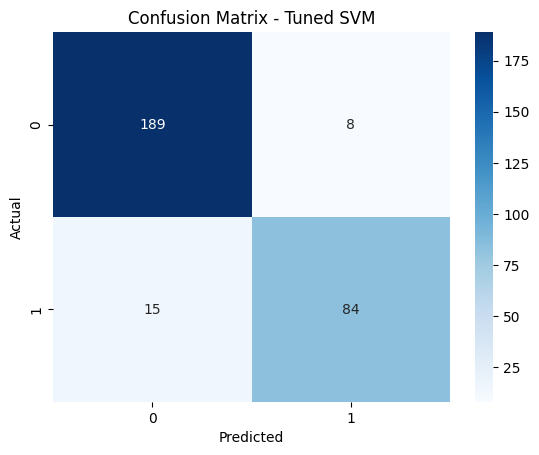

In [11]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

print("\n" + "="*60)
print("SVM PERFORMANCE WITH DIFFERENT KERNELS")
print("="*60)

for kernel in kernels:
    print(f"\n📊 Training SVM with {kernel.upper()} kernel...")
    
    # Create and train SVM model
    svm = SVC(kernel=kernel, random_state=42, C=1.0)
    svm.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = svm.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results[kernel] = {
        'model': svm,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"   Test Accuracy: {accuracy:.4f}")
    print(f"   Support Vectors: {svm.n_support_}")
    print(f"   Total Support Vectors: {len(svm.support_vectors_)}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### SVM Kernels Explained:

| Kernel | Description | When to Use |
|--------|-------------|-------------|
| **Linear** | Creates a straight line/hyperplane separator | When data is linearly separable |
| **Polynomial** | Uses polynomial function to create curved boundaries | For moderately complex relationships |
| **RBF (Radial Basis Function)** | Most popular, creates complex non-linear boundaries | Default choice, works well for most datasets |
| **Sigmoid** | Similar to neural network activation function | For specific patterns, less common |

**Key Observations from Visualization:**
- Different kernels create different decision boundaries
- Support vectors are the critical points that define the margin
- RBF kernel often provides the most flexible boundary

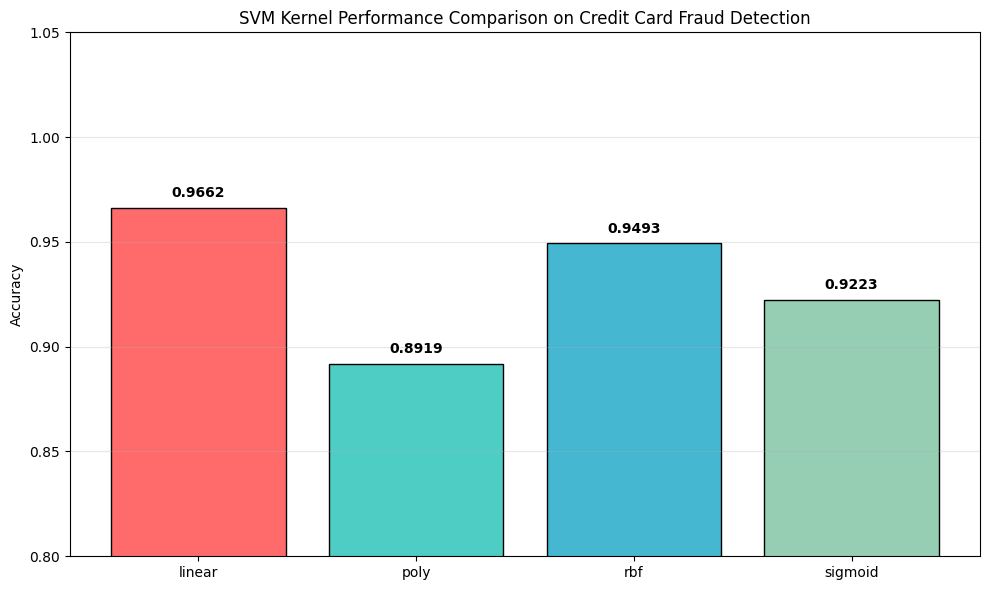

In [12]:
# Accuracy comparison bar chart
plt.figure(figsize=(10, 6))
accuracies = [results[k]['accuracy'] for k in kernels]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(kernels, accuracies, color=colors, edgecolor='black')
plt.ylabel('Accuracy')
plt.title('SVM Kernel Performance Comparison on Credit Card Fraud Detection')
plt.ylim(0.8, 1.05)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


DETAILED EVALUATION - LINEAR KERNEL

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.98       197
       Fraud       1.00      0.90      0.95        99

    accuracy                           0.97       296
   macro avg       0.98      0.95      0.96       296
weighted avg       0.97      0.97      0.97       296



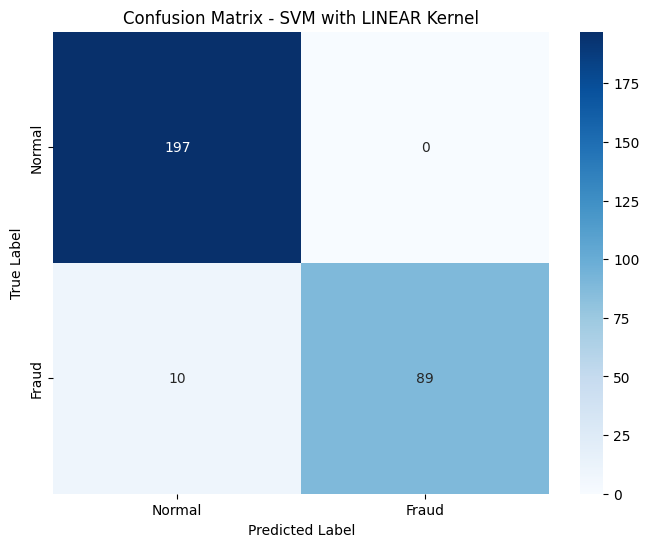

In [13]:

# Find the best kernel
best_kernel = max(results, key=lambda k: results[k]['accuracy'])
best_svm = results[best_kernel]['model']
y_pred_best = results[best_kernel]['predictions']

print("\n" + "="*60)
print(f"DETAILED EVALUATION - {best_kernel.upper()} KERNEL")
print("="*60)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix - SVM with {best_kernel.upper()} Kernel')
plt.show()